In [1]:
import torch
import torch.nn as nn 
import torch.nn.functional as F
import os
import sys
from tqdm import tqdm
project_root = '/public/home/zhangshikang/project/decouple_detr/DecoupleDETR/'
if project_root not in sys.path:
    sys.path.insert(0, project_root)
os.chdir(project_root)
from dataset import (build_dataset, build_loader,build_semi_weak_dataloader)
from models import build_model

/public/home/zhangshikang/.conda/envs/detr/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/public/home/zhangshikang/.conda/envs/detr/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
check_point = '/public/home/zhangshikang/project/DATA/models/weak/for_test/epoch_19.pth'
model_dict = torch.load(check_point, map_location='cuda:0',weights_only=False)
model,criterion,postprocessor = build_model(model_dict['config'])
model.load_state_dict(model_dict['model_state_dict'])

/public/home/zhangshikang/.conda/envs/detr/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/public/home/zhangshikang/.conda/envs/detr/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


<All keys matched successfully>

#### test base task
- predicting the percentage of cells in each patch

loading data

In [3]:
data_dict = model_dict['config']
data_dict.dataset['root'] = '/public/home/zhangshikang/project/DATA/weak_data/split_train/eval'
data_dict.dataset['train_pct'] = 1.0
tissues = model_dict['config'].dataset['tissue']

In [4]:
tissues

['kidney', 'lung', 'prostate']

In [5]:
model = model.to('cuda')
sim_dict = {}
with torch.no_grad():
    for t in tissues:
        data_dict.dataset['tissue'] = [t]
        sim_dict[t] = []
        test_loader,_= build_semi_weak_dataloader(model_dict['config'])
        print(f'test {t}')
        val_tqdm = tqdm(test_loader)
        for img,targets in val_tqdm:
            img = img.to('cuda')
            targets = [{k: v.to('cuda') if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in targets]
            outputs = model(img,targets,stage='test')
            instance_length = outputs['instance_length']
            instance_dis = outputs['decouple_class_logits'].softmax(dim=-1)
            for i, l in enumerate(instance_length):
                instance_dis[i,l:,:]=0
            instance_dis_mean = instance_dis.mean(dim=1)
            targets_ann = [i['weak_label'] for i in targets]
            targets_ann = torch.stack(targets_ann, dim=0)
            sim = F.cosine_similarity(instance_dis_mean, targets_ann, dim=1)
            sim_dict[t] = sim_dict[t] + sim.tolist()


test kidney


  0%|          | 0/375 [00:00<?, ?it/s]/public/home/zhangshikang/.conda/envs/detr/lib/python3.10/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
100%|██████████| 375/375 [01:59<00:00,  3.15it/s]


test lung


100%|██████████| 125/125 [00:44<00:00,  2.83it/s]


test prostate


100%|██████████| 306/306 [01:25<00:00,  3.59it/s]


plot

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

/tmp/ipykernel_749294/565614099.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Tissue', y='Cosine', data=df, inner='quartile', palette='Set2')  # inner='quartile'显示四分位数


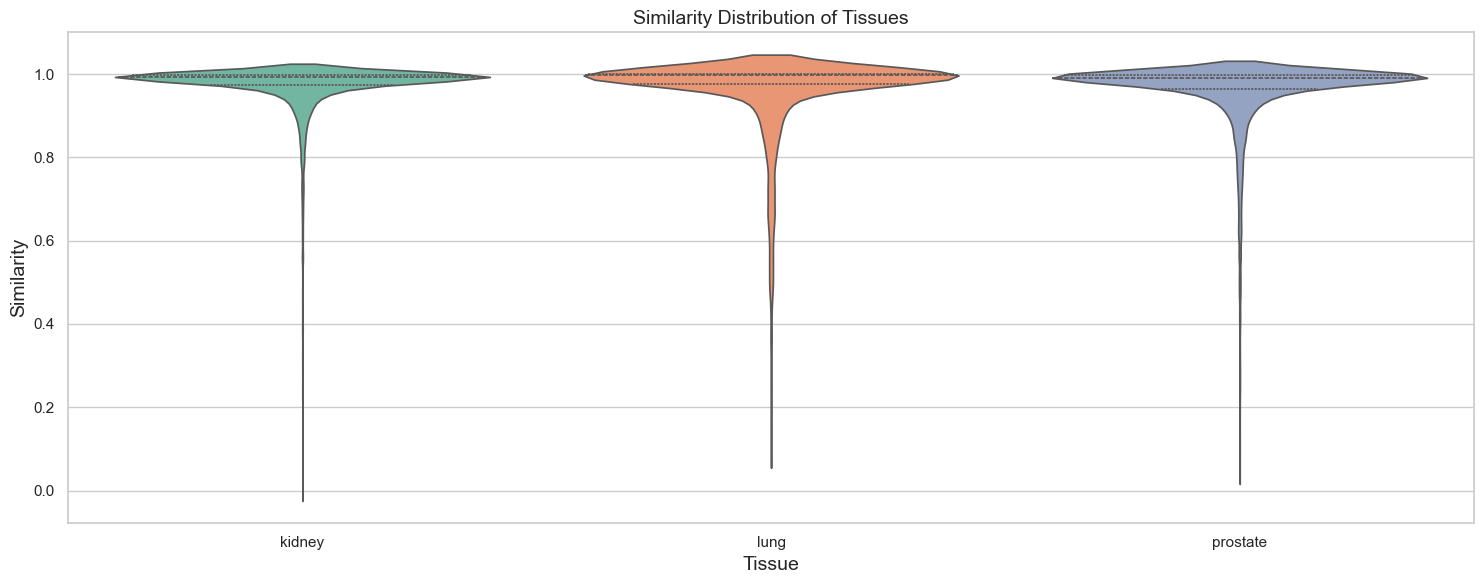

In [10]:
rows = []
for category, values in sim_dict.items():
    for value in values:
        rows.append({'Tissue': category, 'Cosine': value})
df = pd.DataFrame(rows)

# 设置seaborn样式
sns.set(style="whitegrid")

# 创建小提琴图
plt.figure(figsize=(15, 6))  # 设置图表大小
sns.violinplot(x='Tissue', y='Cosine', data=df, inner='quartile', palette='Set2')  # inner='quartile'显示四分位数

# 添加标题和标签
plt.title('Similarity Distribution of Tissues', fontsize=14)
plt.xlabel('Tissue', fontsize=14)
plt.ylabel('Similarity', fontsize=14)

# 显示图表
plt.tight_layout()  # 调整布局
plt.savefig("similarity_distribution.png", dpi=300, bbox_inches="tight")

In [11]:
stats = df.groupby('Tissue')['Cosine'].agg(['mean', 'median', 'std', 'min', 'max']).reset_index()
print("统计值:")
print(stats)

统计值:
     Tissue      mean    median       std       min       max
0    kidney  0.970049  0.992097  0.070716  0.000000  0.999940
1      lung  0.955322  0.996933  0.106402  0.101391  0.999940
2  prostate  0.959602  0.990643  0.086860  0.047719  0.999997


In [12]:
sns.set(style="white")

# 创建画布
plt.figure(figsize=(15, 8))

# 绘制小提琴图
ax = sns.violinplot(x='Tissue', y='Cosine', data=df, inner='quartile', palette='Set2')

# 标注统计值
for i, row in stats.iterrows():
    category = row['Tissue']
    mean_val = row['mean']
    median_val = row['median']
    std_val = row['std']
    
    # 获取当前类别的x坐标（小提琴图的中心位置）
    x_pos = i  # 假设类别是按顺序排列的
    
    # 标注均值（用红色星号）
    ax.plot(x_pos, mean_val, 'r*', markersize=12, label='mean' if i == 0 else "")
    
    # 标注中位数（用蓝色三角形）
    ax.plot(x_pos, median_val, 'b^', markersize=12, label='median' if i == 0 else "")
    
    # 在图上添加文本标注（显示具体数值）
    ax.text(x_pos + 0.2, mean_val, f"mean: {mean_val:.2f}", fontsize=12, color='red')
    ax.text(x_pos + 0.2, median_val, f"median: {median_val:.2f}", fontsize=12, color='blue')

# 添加标题和标签
plt.title('Similarity Distribution of Tissues', fontsize=16)
plt.xlabel('Tissue', fontsize=14)
plt.xticks(fontsize=14)  # 设置x轴刻度字体大小
plt.ylabel('Similarity', fontsize=14)

# 添加图例
plt.legend(loc='upper left')

# 调整布局
plt.tight_layout()
plt.savefig('paper_figure/similarity_distribution_weak.png', dpi=300)
plt.close()

/tmp/ipykernel_749294/3991321223.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(x='Tissue', y='Cosine', data=df, inner='quartile', palette='Set2')


### test on pannuke

In [3]:
test_dataset = build_dataset(model_dict['config'], split='test')
test_loader = build_loader(model_dict['config'], test_dataset,split='test')

loading annotations into memory...
Done (t=0.91s)
creating index...
index created!


In [4]:
from eval.pannuke_eval import CellDetectionMetric
from tqdm import tqdm
from util import box_ops

In [5]:
CELL_LIST = ['T','Myeloid','Malignant','NK','Mast','Fibroblast','Epithelial','Endothelial','B','Plasma','SMC','Pericyte','Dendritic']

In [6]:
def map_tensor_values(tensor, mapping_dict):
    """
    according to the mapping_dict, map the values in tensor to new values.
    """
    result = tensor.clone()  # 创建tensor的副本以避免修改原始tensor
    for old_val, new_val in mapping_dict.items():
        result[torch.where(result == old_val)] = new_val
    return result

In [7]:
def accumulate_tensor_values(tensor, mapping_dict):
    """
    简化版本，避免复杂的scatter操作
    """
    # 创建新tensor
    reshaped_tensor = torch.zeros(tensor.shape[:-1] + (5,), device=tensor.device, dtype=tensor.dtype)
    
    # 直接遍历映射字典
    for old_val, new_val in mapping_dict.items():
        if new_val < 5:  # 确保新值在0-4范围内
            reshaped_tensor[..., new_val] += tensor[..., old_val]
    
    # 确保第三维为0
    # reshaped_tensor[..., 2] = 0
    
    return reshaped_tensor
     

In [11]:
metrics = {
        #'map' : torchmetrics.detection.MeanAveragePrecision(box_format='cxcywh'),
        'f'   : CellDetectionMetric(num_classes=5, 
                                    thresholds=0.2,
                                    max_pair_distance=12,
                                    class_names=test_dataset.class_names)
            }
map_dict = {
    0: 1,
    1: 1,
    2: 0,
    3: 1,
    4: 0,
    5: 2,
    6: 4,
    7: 2,
    8: 1,
    9: 1,
    10:2,
    11:2,
    12:1
}
### version 2
model = model.to('cuda')
for imgs,targets in tqdm(test_loader):
    imgs = imgs.tensors.to('cuda')
    model.eval()
    outputs_ = {}
    with torch.no_grad():
        outputs = model(imgs,targets,stage='test',threshold=0.4)
        instance_logits = outputs['decouple_class_logits']
        instance_logits = torch.logit(accumulate_tensor_values(instance_logits.softmax(dim=-1), map_dict))
        instance_length = outputs['instance_length']
        instance_boxes = outputs['instance_boxes']
        for i, l in enumerate(instance_length):
            instance_boxes[i,l:,:2] = 2
            instance_logits[i,l:,:] = -100 
    outputs_['pred_logits'] = instance_logits.clone().cpu()
    outputs_['pred_boxes'] = instance_boxes.clone().cpu()
    orig_target_sizes = torch.stack([torch.tensor(t["boxes"].canvas_size) for t in targets], dim=0)
    predictions = postprocessor['bbox'](outputs_, orig_target_sizes)
    for p in predictions:
        # convert boxes
        p['boxes'] = box_ops.box_xyxy_to_cxcywh(p['boxes'])
        
        # p['labels'] = map_tensor_values(p['labels'], map_dict)
    # prepare targets
    for t in targets:
        # get image size
        #img_h, img_w = data_loader.dataset.image_size(image_id=t["image_id"])
        img_h, img_w = t['boxes'].canvas_size
        # convert boxes
        t['boxes'] = box_ops.denormalize_box(t['boxes'], (img_h, img_w))
    # update metrics
    for k in metrics:
        metrics[k].update(predictions, targets)
metrics = {k: metrics[k].compute() for k in metrics}

100%|██████████| 332/332 [00:25<00:00, 13.14it/s]


In [12]:
instance_logits.sigmoid()

tensor([[[0.3976, 0.1857, 0.1509, 0.0000, 0.2658],
         [0.4698, 0.2002, 0.1994, 0.0000, 0.1306],
         [0.4660, 0.1900, 0.1766, 0.0000, 0.1673],
         ...,
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000]],

        [[0.4046, 0.2461, 0.1915, 0.0000, 0.1578],
         [0.2958, 0.2846, 0.1662, 0.0000, 0.2534],
         [0.2594, 0.3394, 0.2163, 0.0000, 0.1849],
         ...,
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000]],

        [[0.2483, 0.2590, 0.2105, 0.0000, 0.2821],
         [0.1531, 0.3530, 0.2175, 0.0000, 0.2764],
         [0.2936, 0.3260, 0.1643, 0.0000, 0.2161],
         ...,
         [0.2206, 0.3522, 0.1703, 0.0000, 0.2569],
         [0.2146, 0.3425, 0.1759, 0.0000, 0.2670],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000]],

        ...,

        [[0.1488, 0.

In [ ]:
metrics

{'f': {'th02': {'detection': {'f1': 0.7679633162518927,
    'prec': 0.8260909576132369,
    'rec': 0.7174781802487292},
   'neoplastic': {'f1': np.float64(0.32760075658373344),
    'prec': np.float64(0.3175113517782102),
    'rec': np.float64(0.3383524178763562)},
   'inflammatory': {'f1': np.float64(0.26836662416772916),
    'prec': np.float64(0.2268959900349734),
    'rec': np.float64(0.3283871862432395)},
   'connective': {'f1': np.float64(0.17879053461875546),
    'prec': np.float64(0.3329206527855937),
    'rec': np.float64(0.12221120475954388)},
   'necrosis': {'f1': np.float64(0.0),
    'prec': np.float64(nan),
    'rec': np.float64(0.0)},
   'epithelial': {'f1': np.float64(0.07814451382694024),
    'prec': np.float64(0.07846649946255822),
    'rec': np.float64(0.07782515991471216)}}}}

: 

In [1]:
import torch

In [4]:
torch.tensor([[0.5,0.5,1,1]]*4)

tensor([[0.5000, 0.5000, 1.0000, 1.0000],
        [0.5000, 0.5000, 1.0000, 1.0000],
        [0.5000, 0.5000, 1.0000, 1.0000],
        [0.5000, 0.5000, 1.0000, 1.0000]])